In [175]:
import os # for working with file paths
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
import numpy as np # for numerical operations
from statsmodels.tsa.stattools import adfuller, kpss # for stationary tests in time series analysis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # for plotting autocorrelation and partial autocorrelation functions
from statsmodels.stats.diagnostic import acorr_ljungbox # for Ljung-Box test to check for autocorrelation in residuals

In [176]:
# pip install -r requirements.txt

In [177]:
# Set default figure size for all plots
plt.rcParams['figure.figsize'] = (10, 6)  # width, height in inches

# Font size constants for consistent styling
TITLE_FONTSIZE = 11        # For plot titles and suptitles
LABEL_FONTSIZE = 9       # For axis labels on normal plots
SMALL_LABEL_FONTSIZE = 7   # For axis labels on dense plots
TICK_LABEL_FONTSIZE = 6    # For tick labels on dense plots

## Loading data

Please download the `Household Data`, `Time series` and `Weather Data` datasets from the [following link](https://open-power-system-data.org/?fbclid=IwY2xjawQrXChleHRuA2FlbQIxMABicmlkETAySk9Rek9iRlhadG5obFY2c3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHrxVocPQPnX3w-NtGDF0CzSaMXon2ozmHkI4GrpsZ26X0-5tdyYfNkCLztn8_aem_VLIgUHUoLSYcNf8ToLLKHw) and save them in the `data/raw/` directory. Your directory should look like this:
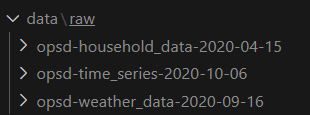

In [178]:
cwd = os.getcwd()

parent_dir = os.path.dirname(cwd)
data_dir = os.path.join(parent_dir, 'data/raw')
household_data_path = os.path.join(data_dir, 'opsd-household_data-2020-04-15/household_data_60min_singleindex.csv')
time_series_data_path = os.path.join(data_dir, 'opsd-time_series-2020-10-06/time_series_60min_singleindex.csv')
weather_data_path = os.path.join(data_dir, 'opsd-weather_data-2020-09-16/weather_data.csv')

household_data = pd.read_csv(household_data_path, index_col=0, parse_dates=True)
time_series_data = pd.read_csv(time_series_data_path, index_col=0, parse_dates=True)
weather_data = pd.read_csv(weather_data_path, index_col=0, parse_dates=True)

### Household Dataset

The dataset contains household and small business energy consumption and generation data in kWh from MID-certified metering devices. Data is cumulative, so overall energy consumption/generation is retained despite occasional gaps. Households report grid import/export values, with some having Photovoltaic (PV) systems.

In [179]:
household_data.head(3)

,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:00:00+00:00,2014-12-11T18:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+00:00,2014-12-11T20:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [180]:
household_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38454 entries, 2014-12-11 17:00:00+00:00 to 2019-05-01 22:00:00+00:00
Data columns (total 70 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   cet_cest_timestamp                   38454 non-null  object 
 1   DE_KN_industrial1_grid_import        16434 non-null  float64
 2   DE_KN_industrial1_pv_1               17288 non-null  float64
 3   DE_KN_industrial1_pv_2               17288 non-null  float64
 4   DE_KN_industrial2_grid_import        11279 non-null  float64
 5   DE_KN_industrial2_pv                 12000 non-null  float64
 6   DE_KN_industrial2_storage_charge     9754 non-null   float64
 7   DE_KN_industrial2_storage_decharge   9754 non-null   float64
 8   DE_KN_industrial3_area_offices       14360 non-null  float64
 9   DE_KN_industrial3_area_room_1        14360 non-null  float64
 10  DE_KN_industrial3_area_room_2        14360 non-

### Overview of available columns

Apart from the `cet_cest_timestamp` and `interpolated` columns, all data columns are prefixed with `DE_KN`, indicating measurements from the German trial site in Konstanz. Therefore, we will remove this prefix to make column names more concise and easier to work with.

In [181]:
household_data.columns = household_data.columns.str.replace('DE_KN_', '', regex=False)
household_data.head(3)

,cet_cest_timestamp,industrial1_grid_import,industrial1_pv_1,industrial1_pv_2,industrial2_grid_import,industrial2_pv,industrial2_storage_charge,industrial2_storage_decharge,industrial3_area_offices,industrial3_area_room_1,...,residential5_refrigerator,residential5_washing_machine,residential6_circulation_pump,residential6_dishwasher,residential6_freezer,residential6_grid_export,residential6_grid_import,residential6_pv,residential6_washing_machine,interpolated
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:00:00+00:00,2014-12-11T18:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+00:00,2014-12-11T20:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Both `utc_timestamp` and `cet_cest_timestamp` represent the same time but in different time zones. The `cet_cest_timestamp` column is stored as a string, whereas `utc_timestamp` is already in the correct datetime format. 

Converting `cet_cest_timestamp` to datetime would require handling mixed timezones (CET and CEST), which would necessitate conversion to a common timezone such as UTC. Since we already have the time information available in the properly formatted `utc_timestamp` index, we will focus our analysis on that column. 

In [182]:
household_data = household_data.drop('cet_cest_timestamp', axis=1)

The dataset comprises of three distinct building types, industrial, public, and residential, representing a total of 11 buildings. To simplify our analysis and avoid the inherent complexity of modeling across different building types, we will focus on predicting electricity demand for a single household. 

We choose to focus on Residential4, which has the most complete data and the highest number of energy features (9) recorded among the residential buildings.

### Residential data

In [183]:
# data related to residential buildings
residential4_data = household_data.filter(regex='^residential4_')

# drop 'residential4' suffix for cleaner column names
residential4_data.columns = residential4_data.columns.str.replace('residential4_', '', regex=False)
residential4_data.head(3)

,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine
utc_timestamp,,,,,,,,,
2014-12-11 17:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [184]:
residential4_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38454 entries, 2014-12-11 17:00:00+00:00 to 2019-05-01 22:00:00+00:00
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dishwasher       12620 non-null  float64
 1   ev               20288 non-null  float64
 2   freezer          20288 non-null  float64
 3   grid_export      20360 non-null  float64
 4   grid_import      20360 non-null  float64
 5   heat_pump        12311 non-null  float64
 6   pv               20360 non-null  float64
 7   refrigerator     10764 non-null  float64
 8   washing_machine  12258 non-null  float64
dtypes: float64(9)
memory usage: 2.9 MB


#### Residential Building Features

The Residential4 building in our dataset includes measurements for the following energy-related features:

* **dishwasher** - Dishwasher energy consumption in kWh
* **ev** - Electric Vehicle charging energy in kWh
* **freezer** - Freezer energy consumption in kWh
* **grid_export** - Energy exported to the public grid in kWh
* **grid_import** - Energy imported from the public grid in kWh
* **heat_pump** - Heat pump energy consumption in kWh
* **pv** - Total Photovoltaic energy generation in kWh
* **refrigerator** - Refrigerator energy consumption in kWh
* **washing_machine** - Washing machine energy consumption in kWh

Hereafter, all features excluding `grid_export, grid_import, pv` are collectively referred to as **appliances**.

#### Missing data

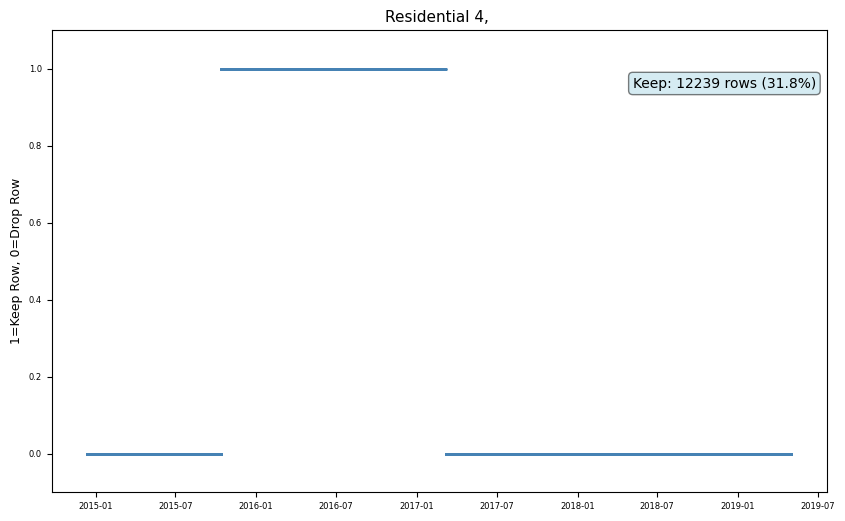

In [185]:
# Calculate missing values
missing_counts = residential4_data.isnull().sum(axis=1)
threshold_val = np.floor(0.2 * residential4_data.shape[1])
keep_row = missing_counts <= threshold_val

plt.scatter(residential4_data.index, keep_row.astype(int), 
                        s=1, alpha=0.6, color='steelblue')
plt.title(f'Residential 4, ', fontsize=TITLE_FONTSIZE)
plt.ylabel('1=Keep Row, 0=Drop Row', fontsize=LABEL_FONTSIZE)
plt.ylim(-0.1, 1.1)
plt.tick_params(labelsize=TICK_LABEL_FONTSIZE)

count = keep_row.sum()
percentage = (count / len(residential4_data)) * 100
plt.text(0.75, 0.9, f'Keep: {count} rows ({percentage:.1f}%)', 
                        transform=plt.gca().transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.show()


In [186]:
start_day = residential4_data.index[keep_row].min()
end_day = residential4_data.index[keep_row].max()

# df containg only residential4 data with adjusted start and end date
residential4_data = residential4_data.loc[
    start_day:end_day, 
    ]

print('Start date:', start_day)
print('End date:', end_day)
print('Number of rows in the period:', len(residential4_data))

Start date: 2015-10-13 16:00:00+00:00
End date: 2017-03-06 14:00:00+00:00
Number of rows in the period: 12239


In [187]:
residential4_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12239 entries, 2015-10-13 16:00:00+00:00 to 2017-03-06 14:00:00+00:00
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dishwasher       12239 non-null  float64
 1   ev               12239 non-null  float64
 2   freezer          12239 non-null  float64
 3   grid_export      12239 non-null  float64
 4   grid_import      12239 non-null  float64
 5   heat_pump        12239 non-null  float64
 6   pv               12239 non-null  float64
 7   refrigerator     10764 non-null  float64
 8   washing_machine  12239 non-null  float64
dtypes: float64(9)
memory usage: 956.2 KB


We still have some missing values for `refrigerator` that we will analyze further.

In [188]:
missing_idx = residential4_data[residential4_data['refrigerator'].isnull()].index
missing_dates = residential4_data.loc[
    residential4_data['refrigerator'].isnull()
].index.date

print(sorted(set(missing_dates)))
missing_per_day = residential4_data['refrigerator'].isnull().groupby(
    residential4_data.index.date
).sum()

print("Missing per day")
print(missing_per_day[missing_per_day > 0])
missing = residential4_data['refrigerator'].isnull()

print("\nConsecutive missing blocks")
groups = (missing != missing.shift()).cumsum()
missing_blocks = residential4_data[missing].groupby(groups).size()

print(missing_blocks)

[datetime.date(2015, 10, 13), datetime.date(2015, 10, 14), datetime.date(2017, 1, 4), datetime.date(2017, 1, 5), datetime.date(2017, 1, 6), datetime.date(2017, 1, 7), datetime.date(2017, 1, 8), datetime.date(2017, 1, 9), datetime.date(2017, 1, 10), datetime.date(2017, 1, 11), datetime.date(2017, 1, 12), datetime.date(2017, 1, 13), datetime.date(2017, 1, 14), datetime.date(2017, 1, 15), datetime.date(2017, 1, 16), datetime.date(2017, 1, 17), datetime.date(2017, 1, 18), datetime.date(2017, 1, 19), datetime.date(2017, 1, 20), datetime.date(2017, 1, 21), datetime.date(2017, 1, 22), datetime.date(2017, 1, 23), datetime.date(2017, 1, 24), datetime.date(2017, 1, 25), datetime.date(2017, 1, 26), datetime.date(2017, 1, 27), datetime.date(2017, 1, 28), datetime.date(2017, 1, 29), datetime.date(2017, 1, 30), datetime.date(2017, 1, 31), datetime.date(2017, 2, 1), datetime.date(2017, 2, 2), datetime.date(2017, 2, 3), datetime.date(2017, 2, 4), datetime.date(2017, 2, 5), datetime.date(2017, 2, 6), d

The results show a small number of missing observations in October 2015 and a large continuous gap of 1459 observations, corresponding to approximately two months (January–March 2017). During this period, most days contain either fully or almost fully missing values. Given this large missing block, imputing the data would require reconstructing a long period of values, which could introduce bias.

Therefore, instead of directly imputing, we will first evaluate whether the refrigerator variable is important for predicting the target variable

`Intarpolated` is a marker indicating which columns in the source data are missing and have been interpolated. 

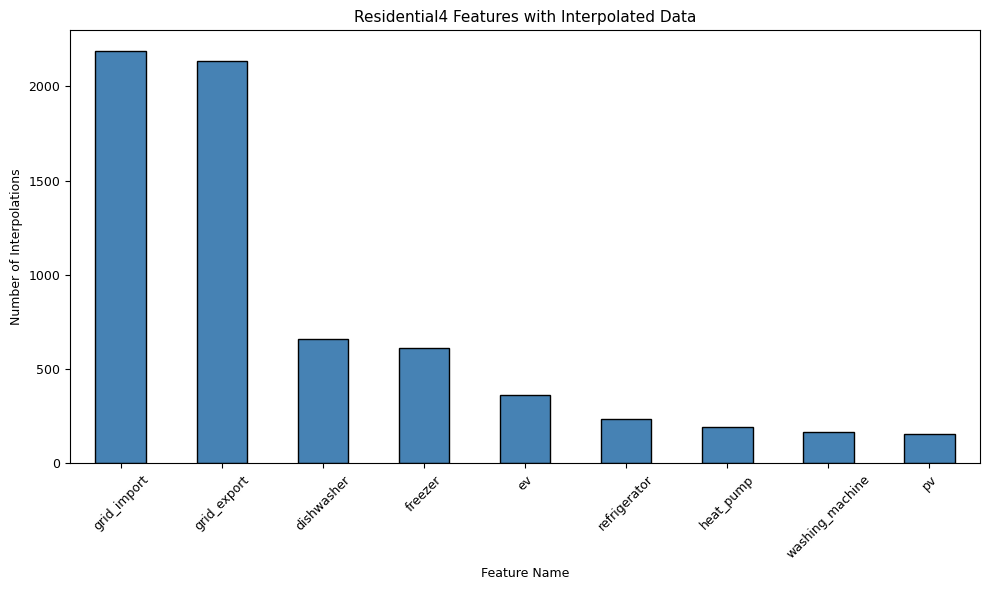

In [189]:
# Distribution of values in the 'interpolated' column (Residential4 only)
interpolated_data = household_data.loc[start_day:end_day]['interpolated'].copy()

# Remove 'DE_KN_' prefix from strings in the 'interpolated' column
interpolated_data = interpolated_data.str.replace('DE_KN_', '', regex=False)

# Split by space and explode to get individual words
interpolated_data = interpolated_data.str.split().explode()

# Filter to keep only words that contain 'residential4'
interpolated_data = interpolated_data[interpolated_data.str.contains('residential4', case=False, na=False)]

# Remove 'residential4_' prefix to get feature names
interpolated_data = interpolated_data.str.replace('residential4_', '', regex=False)

# Remove empty strings and NaN values
interpolated_data = interpolated_data[interpolated_data.notna() & (interpolated_data != '')]

fig, ax = plt.subplots(figsize=(10, 6))
interpolated_data.value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Residential4 Features with Interpolated Data', fontsize=TITLE_FONTSIZE)
ax.set_xlabel('Feature Name', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Number of Interpolations', fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=LABEL_FONTSIZE)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

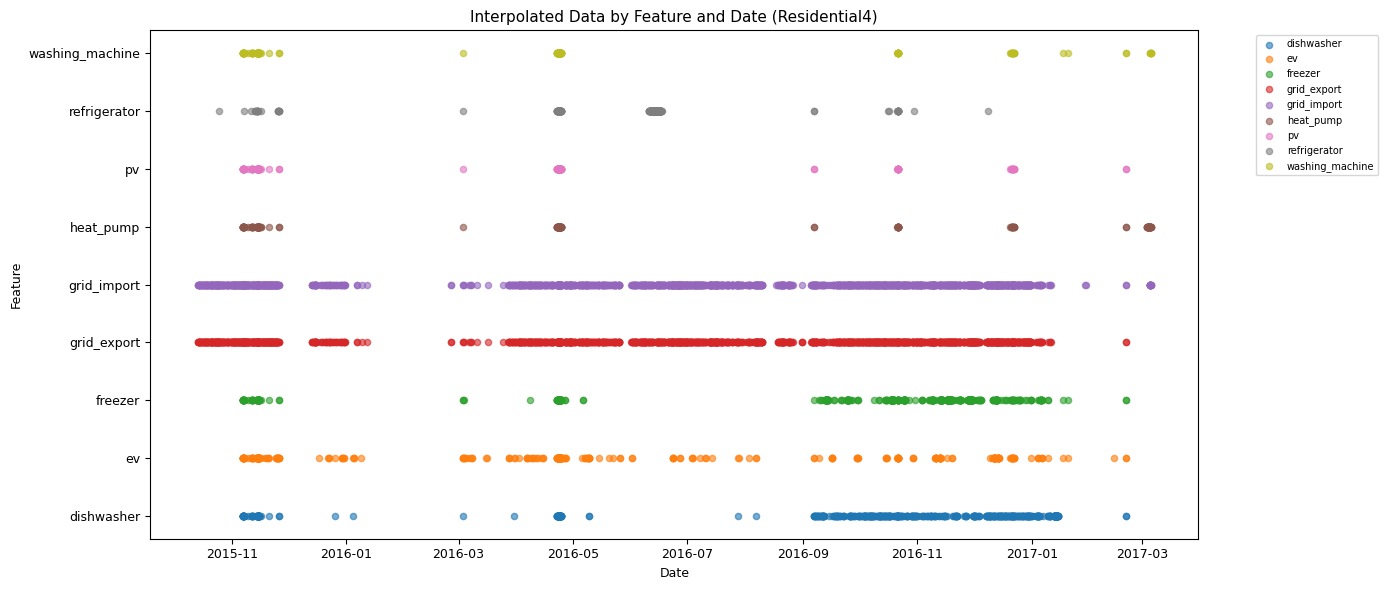

In [190]:
interpolated_df = pd.DataFrame({
    'date': interpolated_data.index,
    'feature': interpolated_data.values
})

# Define the 9 features and assign colors
features_list = ['dishwasher', 'ev', 'freezer', 'grid_export', 'grid_import', 'heat_pump', 'pv', 'refrigerator', 'washing_machine']
colors = plt.cm.tab10(range(len(features_list)))
color_map = {feature: colors[i] for i, feature in enumerate(features_list)}

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 6))

for feature in features_list:
    mask = interpolated_df['feature'] == feature  # Find all rows with this feature
    ax.scatter(interpolated_df.loc[mask, 'date'],  # X-axis: dates
               [feature] * mask.sum(),              # Y-axis: same feature name repeated
               alpha=0.6, s=20,                     # Transparency and point size
               label=feature, color=color_map[feature])  # Legend + assigned color

ax.set_xlabel('Date', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Feature', fontsize=LABEL_FONTSIZE)
ax.set_title('Interpolated Data by Feature and Date (Residential4)', fontsize=TITLE_FONTSIZE)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=SMALL_LABEL_FONTSIZE)
ax.tick_params(labelsize=LABEL_FONTSIZE)
plt.tight_layout()
plt.show()

#### Data is cummulative

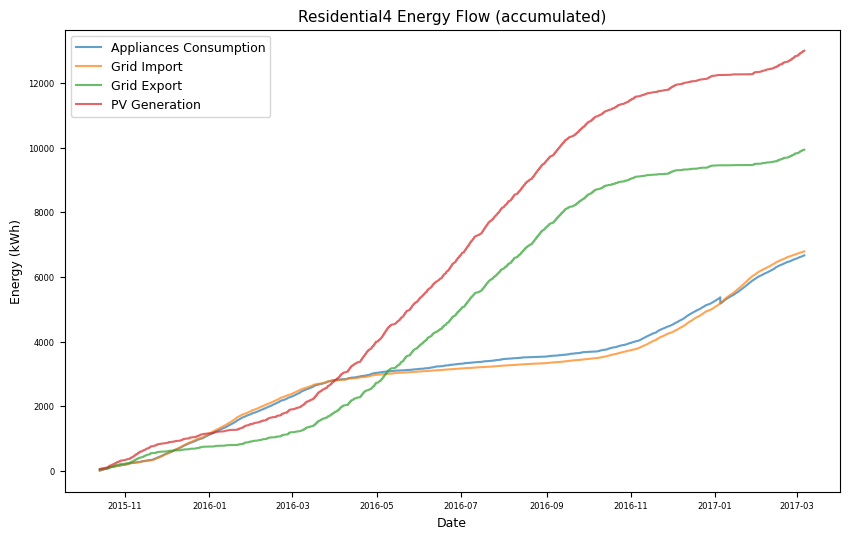

In [191]:
appliances_cols = [col for col in residential4_data.columns  # Exclude grid_import, grid_export, and pv columns
                    if 'grid_import' not in col and 'grid_export' not in col and 'pv' not in col] 

appliances_consumption = residential4_data[appliances_cols].sum(axis=1)

# after group discussion, we decided to exclude "appliances_consumption" from demand calculation
plt.plot(residential4_data.index, appliances_consumption, label='Appliances Consumption', alpha=0.7)  
plt.plot(residential4_data.index, residential4_data['grid_import'], label='Grid Import', alpha=0.7)
plt.plot(residential4_data.index, residential4_data['grid_export'], label='Grid Export', alpha=0.7)
plt.plot(residential4_data.index, residential4_data['pv'], label='PV Generation', alpha=0.7)
plt.title('Residential4 Energy Flow (accumulated)', fontsize=TITLE_FONTSIZE)
plt.xlabel('Date', fontsize=LABEL_FONTSIZE)
plt.ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
plt.legend(fontsize=LABEL_FONTSIZE)
plt.tick_params(labelsize=TICK_LABEL_FONTSIZE)
plt.show()


#### We will consider time series in both daily and hourly resolution.

In [192]:
residential4_data_hourly = residential4_data.copy()
residential4_data_daily = residential4_data.copy().resample('D').mean()

Our first approach is to calculate total energy demand in the household as its photovoltaic production (`pv`) minus the exported energy (`grid_export`) plus `grid_import` to reflect the total energy used.

In [193]:
# perhaps, we should concider energy demend as energy obtain - energy exported
energy_demand_hourly = residential4_data_hourly['grid_import'] + residential4_data_hourly['pv'] - residential4_data_hourly['grid_export']
energy_demand_daily = residential4_data_daily['grid_import'] + residential4_data_daily['pv'] - residential4_data_daily['grid_export']

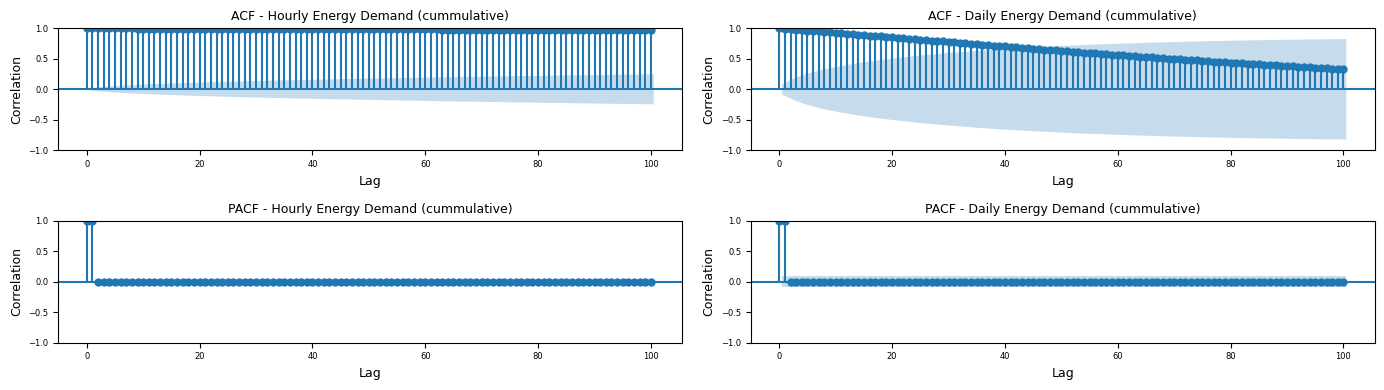

In [194]:
# Plot ACF/PACF on raw cumulative data
fig, axes = plt.subplots(2, 2, figsize=(14, 4))
plot_acf(energy_demand_hourly, lags=100, ax=axes[0, 0])
plot_pacf(energy_demand_hourly, lags=100, ax=axes[1, 0])
plot_acf(energy_demand_daily, lags=100, ax=axes[0, 1])
plot_pacf(energy_demand_daily, lags=100, ax=axes[1, 1])

axes[0, 0].set_title('ACF - Hourly Energy Demand (cummulative)', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_title('PACF - Hourly Energy Demand (cummulative)', fontsize=LABEL_FONTSIZE)
axes[0, 1].set_title('ACF - Daily Energy Demand (cummulative)', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_title('PACF - Daily Energy Demand (cummulative)', fontsize=LABEL_FONTSIZE)

for ax in axes.flat:
    ax.set_xlabel('Lag', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Correlation', fontsize=LABEL_FONTSIZE)
    ax.tick_params(labelsize=TICK_LABEL_FONTSIZE)   
plt.tight_layout()
plt.show()

We will differentiate the data to get the actual values for each time step, which will be more suitable for modeling and analysis.

In [195]:
residential4_data_hourly = residential4_data_hourly.diff().iloc[1:]
appliances_consumption_hourly = residential4_data_hourly[appliances_cols].sum(axis=1)
energy_demand_hourly = residential4_data_hourly['grid_import'] + residential4_data_hourly['pv'] - residential4_data_hourly['grid_export'] 

residential4_data_daily = residential4_data_daily.diff().iloc[1:]
appliances_consumption_daily = residential4_data_daily[appliances_cols].sum(axis=1)
energy_demand_daily = residential4_data_daily['grid_import'] + residential4_data_daily['pv'] - residential4_data_daily['grid_export']

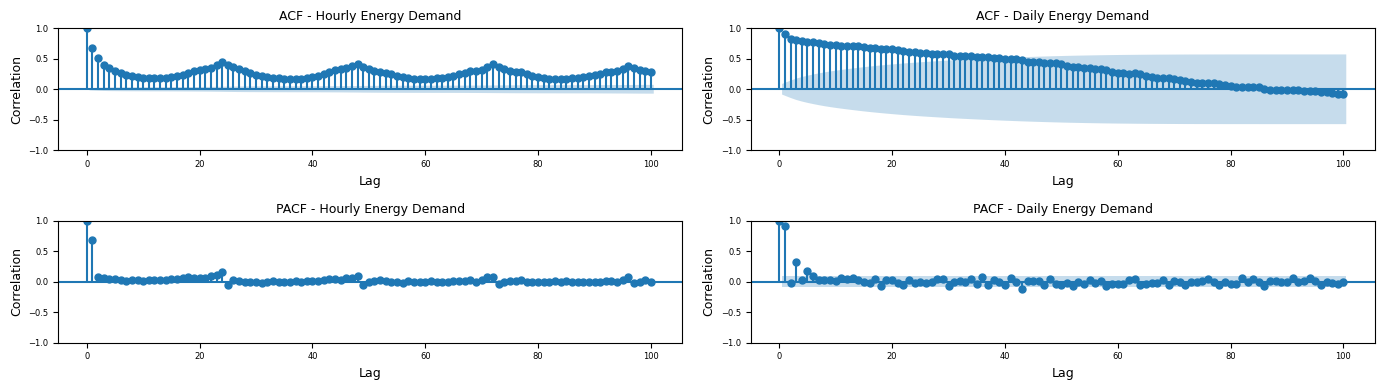

In [196]:
fig, axes = plt.subplots(2, 2, figsize=(14, 4))
plot_acf(energy_demand_hourly, lags=100, ax=axes[0, 0])
plot_pacf(energy_demand_hourly, lags=100, ax=axes[1, 0])
plot_acf(energy_demand_daily, lags=100, ax=axes[0, 1])
plot_pacf(energy_demand_daily, lags=100, ax=axes[1, 1])

axes[0, 0].set_title('ACF - Hourly Energy Demand', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_title('PACF - Hourly Energy Demand', fontsize=LABEL_FONTSIZE)
axes[0, 1].set_title('ACF - Daily Energy Demand', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_title('PACF - Daily Energy Demand', fontsize=LABEL_FONTSIZE)

for ax in axes.flat:
    ax.set_xlabel('Lag', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Correlation', fontsize=LABEL_FONTSIZE)
    ax.tick_params(labelsize=TICK_LABEL_FONTSIZE)
plt.tight_layout()
plt.show()

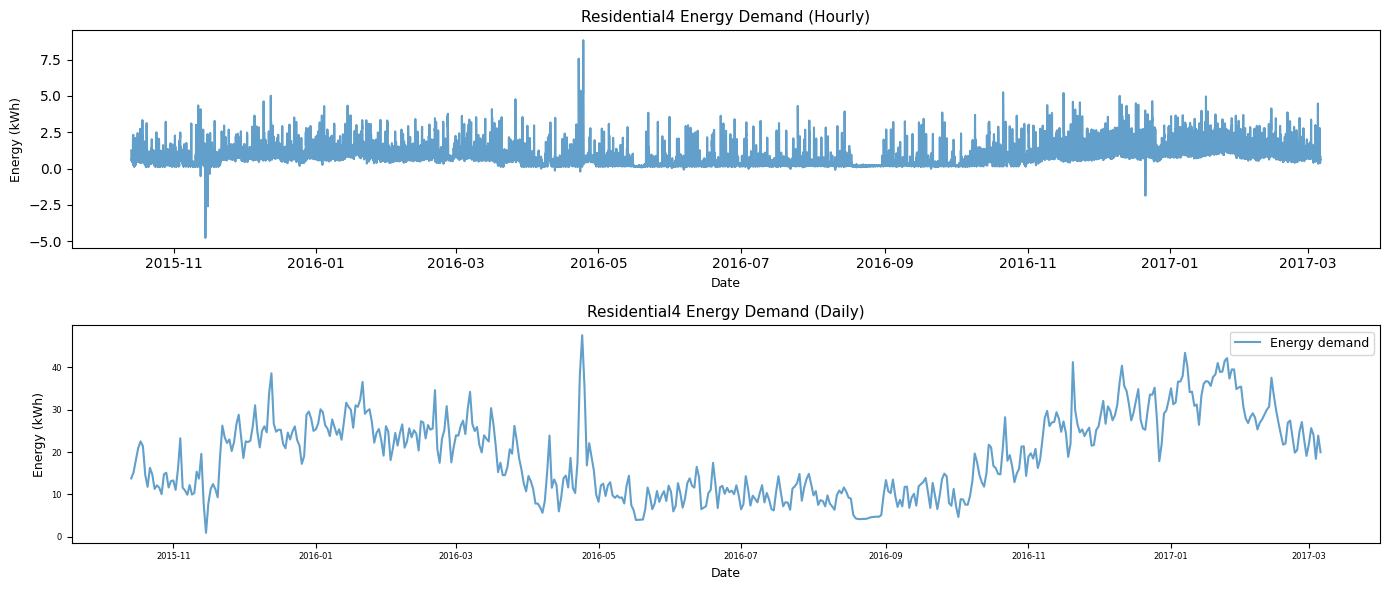

In [197]:
# after group discussion, we decided to exclude "appliances_consumption" from demand calculation
fig, ax = plt.subplots(figsize=(14, 6), nrows=2)

ax[0].plot(residential4_data_hourly.index, energy_demand_hourly, label='Energy demand', alpha=0.7)
ax[1].plot(residential4_data_daily.index, energy_demand_daily, label='Energy demand', alpha=0.7)

ax[0].set_title('Residential4 Energy Demand (Hourly)', fontsize=TITLE_FONTSIZE)
ax[1].set_title('Residential4 Energy Demand (Daily)', fontsize=TITLE_FONTSIZE)
ax[0].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
ax[1].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
ax[0].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
ax[1].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
plt.legend(fontsize=LABEL_FONTSIZE)
plt.tick_params(labelsize=TICK_LABEL_FONTSIZE)
plt.tight_layout()
plt.show()

We obtained negative values for energy demand for some time steps, which indicates that our formula is not accurate in this case. It implies that energy export exceeds energy generation and import in these timesteps. This indicates that the system is not fully observed, potentially due to storage of produced energy, or other unobserved causes. Therefore, we will approximate demand using only `grid_import`, to reflect the energy needs from the energy operator only and treat it as our target variable. We will use energy generation (`pv`).

In [198]:
energy_demand_hourly = residential4_data_hourly['grid_import']
energy_demand_daily = residential4_data_daily['grid_import']

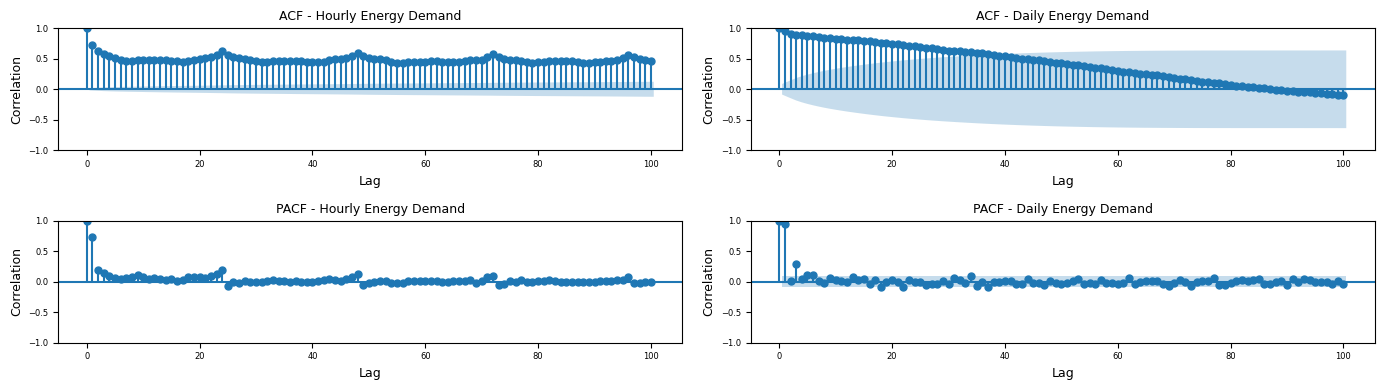

In [199]:
fig, axes = plt.subplots(2, 2, figsize=(14, 4))
plot_acf(energy_demand_hourly, lags=100, ax=axes[0, 0])
plot_pacf(energy_demand_hourly, lags=100, ax=axes[1, 0])
plot_acf(energy_demand_daily, lags=100, ax=axes[0, 1])
plot_pacf(energy_demand_daily, lags=100, ax=axes[1, 1])

axes[0, 0].set_title('ACF - Hourly Energy Demand', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_title('PACF - Hourly Energy Demand', fontsize=LABEL_FONTSIZE)
axes[0, 1].set_title('ACF - Daily Energy Demand', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_title('PACF - Daily Energy Demand', fontsize=LABEL_FONTSIZE)

for ax in axes.flat:
    ax.set_xlabel('Lag', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Correlation', fontsize=LABEL_FONTSIZE)
    ax.tick_params(labelsize=TICK_LABEL_FONTSIZE)
plt.tight_layout()
plt.show()

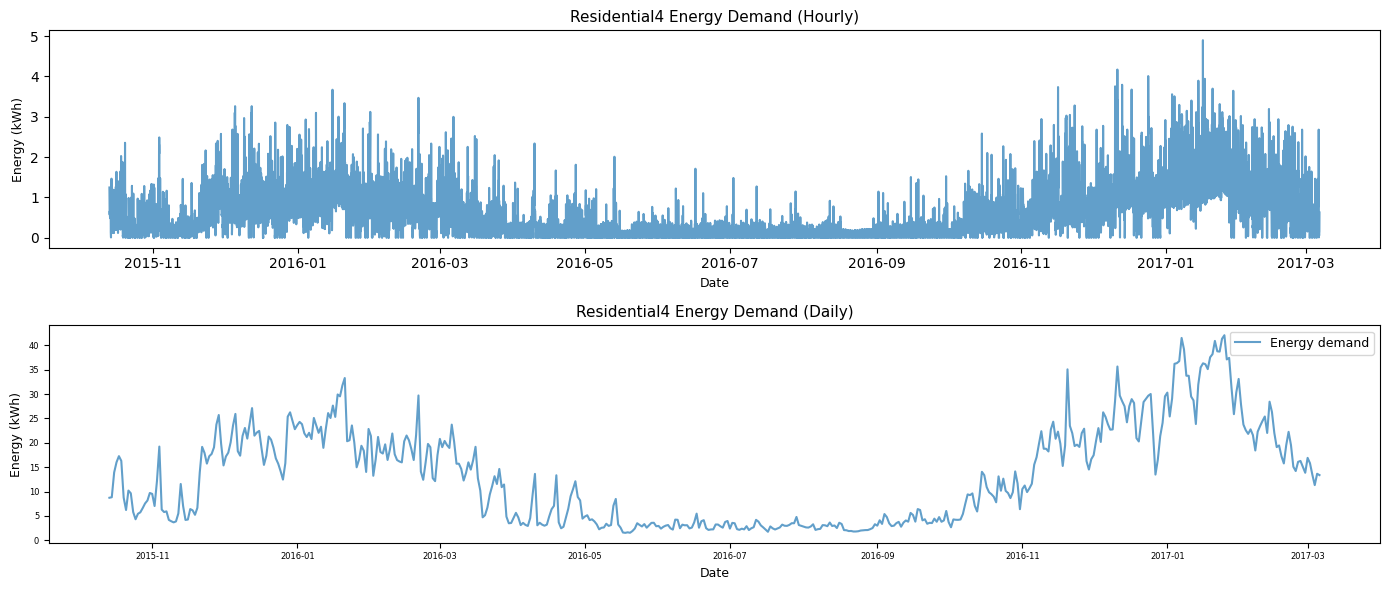

In [200]:
# after group discussion, we decided to exclude "appliances_consumption" from demand calculation
fig, ax = plt.subplots(figsize=(14, 6), nrows=2)

ax[0].plot(residential4_data_hourly.index, energy_demand_hourly, label='Energy demand', alpha=0.7)
ax[1].plot(residential4_data_daily.index, energy_demand_daily, label='Energy demand', alpha=0.7)

ax[0].set_title('Residential4 Energy Demand (Hourly)', fontsize=TITLE_FONTSIZE)
ax[1].set_title('Residential4 Energy Demand (Daily)', fontsize=TITLE_FONTSIZE)
ax[0].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
ax[1].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
ax[0].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
ax[1].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
plt.legend(fontsize=LABEL_FONTSIZE)
plt.tick_params(labelsize=TICK_LABEL_FONTSIZE)
plt.tight_layout()
plt.show()

#### Exploring Residential4 features 

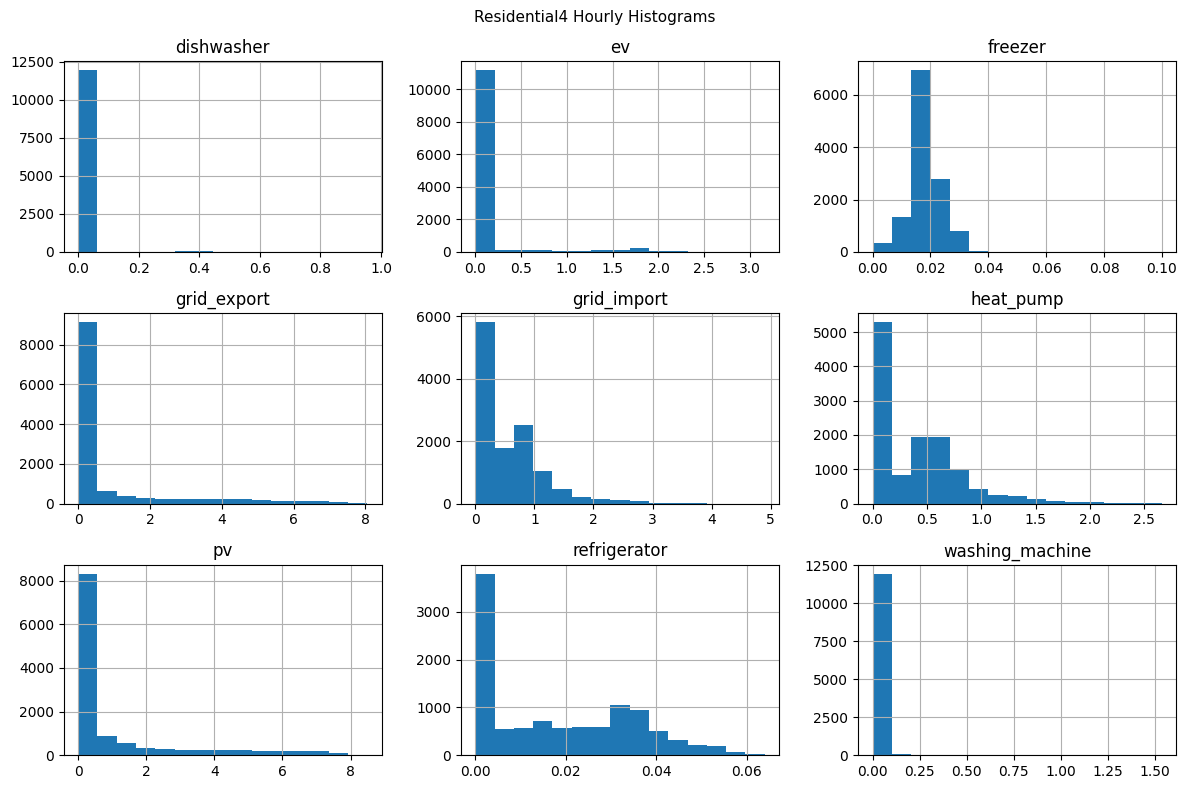

In [201]:
residential4_data_hourly.hist(bins=15, figsize=(12, 8))
plt.suptitle('Residential4 Hourly Histograms', fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

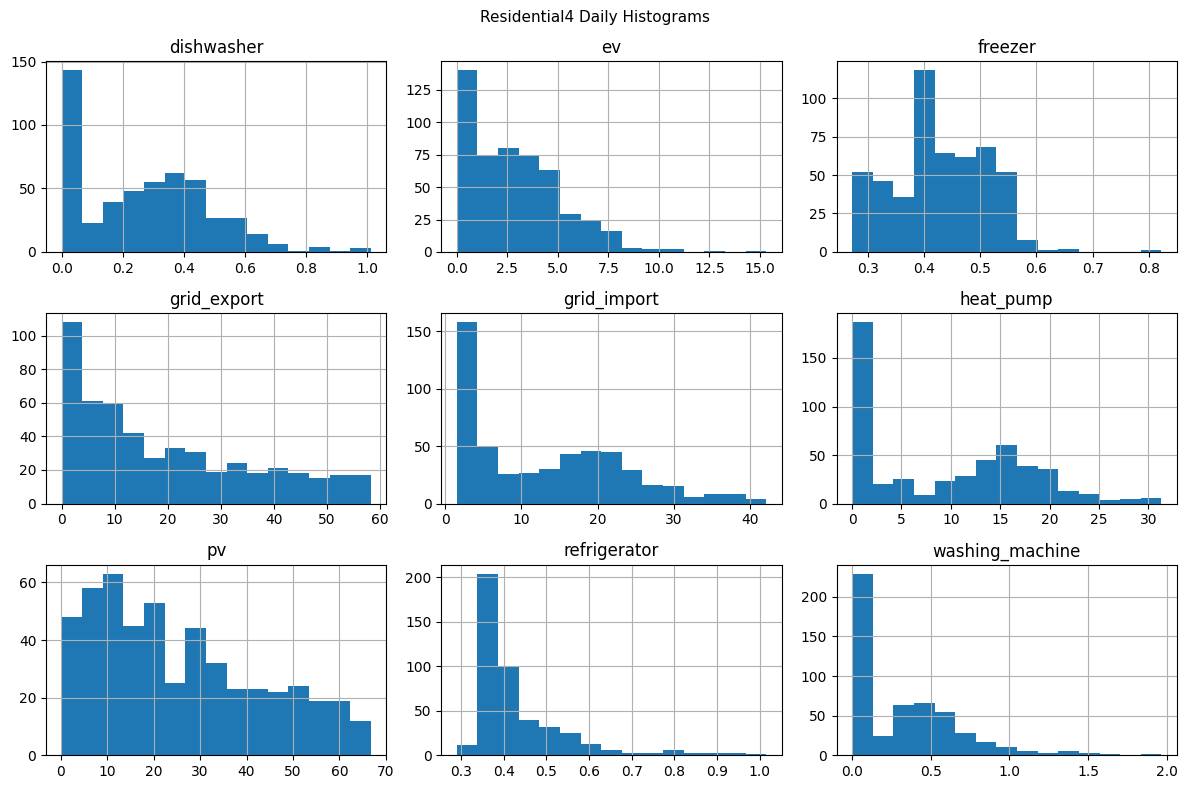

In [202]:
residential4_data_daily.hist(bins=15, figsize=(12, 8))
plt.suptitle('Residential4 Daily Histograms', fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

To analyze the interdependencies between different energy features, focusing on `grid_import` as our target variable, a detailed correlation matrix is computed. This matrix, generated using the Pearson correlation coefficient, measures the linear relationship between pairs of variables, aiding in identifying significant predictors for energy demand.

#### Time Series Analysis

In [203]:
residential4_data_hourly

,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine
utc_timestamp,,,,,,,,,
2015-10-13 17:00:00+00:00,0.002,0.57,0.018,0.000,1.248,0.470,0.000,NaN,0.002
2015-10-13 18:00:00+00:00,0.000,0.00,0.026,0.000,0.765,0.530,0.000,NaN,0.000
2015-10-13 19:00:00+00:00,0.000,0.00,0.020,0.000,0.701,0.430,0.000,NaN,0.000
2015-10-13 20:00:00+00:00,0.000,0.00,0.017,0.000,0.573,0.350,0.000,NaN,0.000
2015-10-13 21:00:00+00:00,0.000,0.00,0.029,0.000,0.662,0.436,0.000,NaN,0.000
...,...,...,...,...,...,...,...,...,...
2017-03-06 10:00:00+00:00,0.000,0.00,0.012,1.724,0.051,0.240,2.055,NaN,0.000
2017-03-06 11:00:00+00:00,0.000,0.00,0.006,0.980,0.109,0.440,1.505,NaN,0.000
2017-03-06 12:00:00+00:00,0.000,0.00,0.017,1.010,0.111,0.430,1.505,NaN,0.000


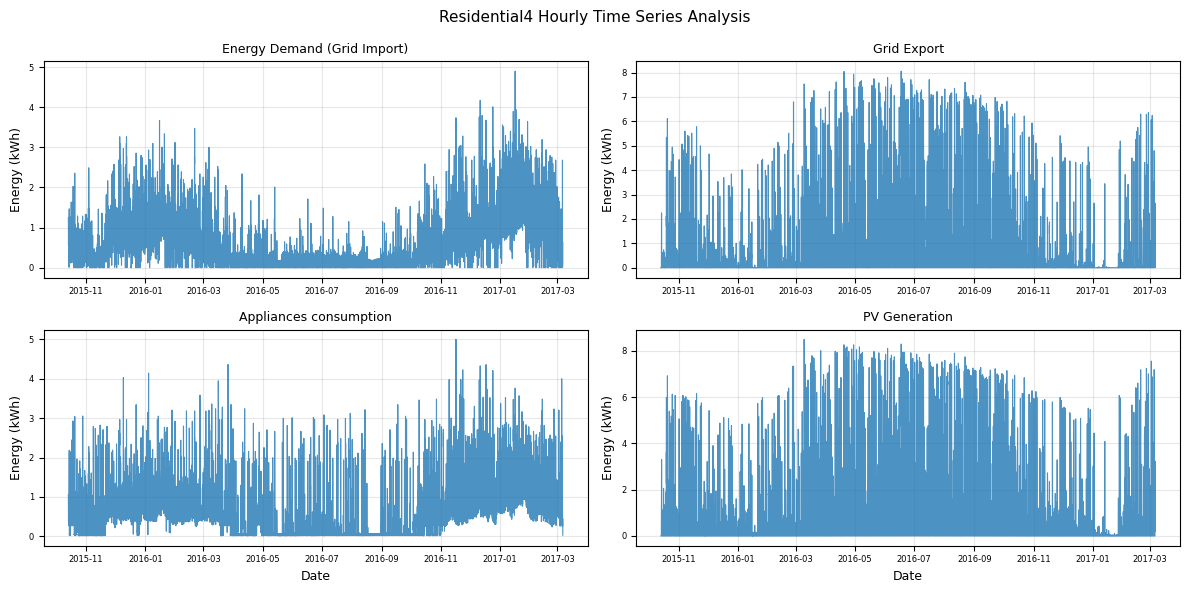

In [204]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Residential4 Hourly Time Series Analysis', fontsize=TITLE_FONTSIZE)

# Grid Import
axes[0, 0].plot(residential4_data_hourly.index, residential4_data_hourly['grid_import'], 
                linewidth=0.8, alpha=0.8)
axes[0, 0].set_title('Energy Demand (Grid Import)', fontsize=LABEL_FONTSIZE)
axes[0, 0].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[0, 0].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[0, 0].grid(True, alpha=0.3)

# Grid Export
axes[0, 1].plot(residential4_data_hourly.index, residential4_data_hourly['grid_export'], 
                linewidth=0.8, alpha=0.8)
axes[0, 1].set_title('Grid Export', fontsize=LABEL_FONTSIZE)
axes[0, 1].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[0, 1].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[0, 1].grid(True, alpha=0.3)

# Consumption (not used for modeling, but good to visualize)
axes[1, 0].plot(residential4_data_hourly.index, appliances_consumption_hourly, 
                linewidth=0.8, alpha=0.8)
axes[1, 0].set_title('Appliances consumption', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
axes[1, 0].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[1, 0].grid(True, alpha=0.3)

# PV Generation
axes[1, 1].plot(residential4_data_hourly.index, residential4_data_hourly['pv'], 
                linewidth=0.8, alpha=0.8)
axes[1, 1].set_title('PV Generation', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
axes[1, 1].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


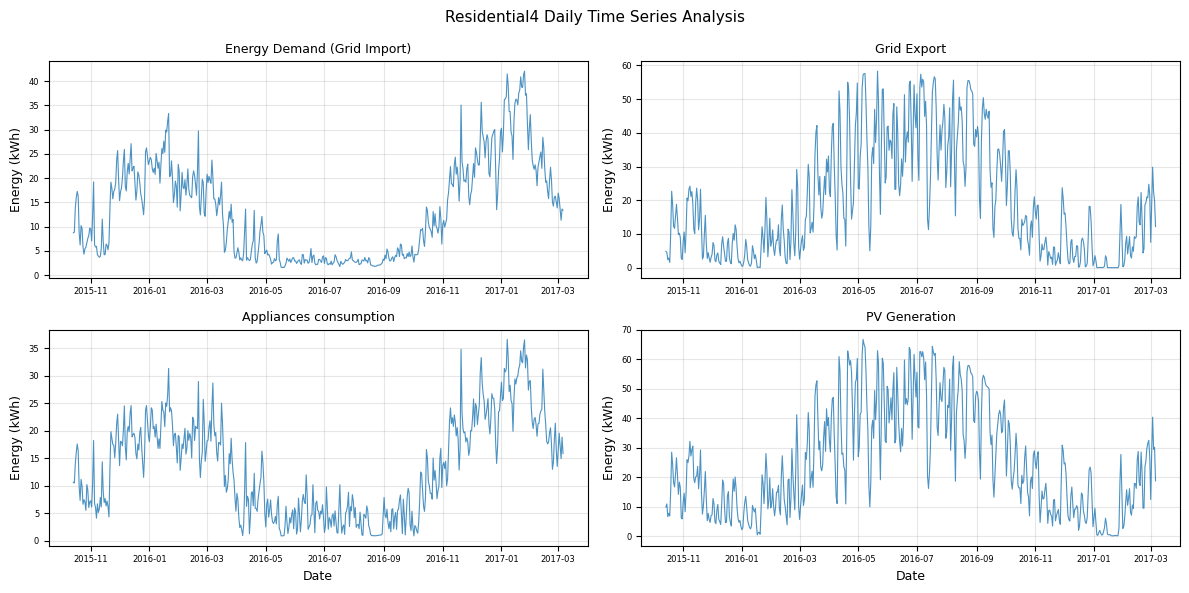

In [205]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Residential4 Daily Time Series Analysis', fontsize=TITLE_FONTSIZE)

# Grid Import
axes[0, 0].plot(residential4_data_daily.index, residential4_data_daily['grid_import'], 
                linewidth=0.8, alpha=0.8)
axes[0, 0].set_title('Energy Demand (Grid Import)', fontsize=LABEL_FONTSIZE)
axes[0, 0].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[0, 0].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[0, 0].grid(True, alpha=0.3)

# Grid Export
axes[0, 1].plot(residential4_data_daily.index, residential4_data_daily['grid_export'], 
                linewidth=0.8, alpha=0.8)
axes[0, 1].set_title('Grid Export', fontsize=LABEL_FONTSIZE)
axes[0, 1].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[0, 1].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[0, 1].grid(True, alpha=0.3)

# Consumption (not used for modeling, but good to visualize)
axes[1, 0].plot(residential4_data_daily.index, appliances_consumption_daily, 
                linewidth=0.8, alpha=0.8)
axes[1, 0].set_title('Appliances consumption', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[1, 0].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
axes[1, 0].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[1, 0].grid(True, alpha=0.3)

# PV Generation
axes[1, 1].plot(residential4_data_daily.index, residential4_data_daily['pv'], 
                linewidth=0.8, alpha=0.8)
axes[1, 1].set_title('PV Generation', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_ylabel('Energy (kWh)', fontsize=LABEL_FONTSIZE)
axes[1, 1].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
axes[1, 1].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [206]:
def adfuller_test(series, sig = 0.05):
    res = adfuller(series, autolag='AIC')    
    p_value = round(res[1], 3) 
    stats   = round(res[0], 3) 

    if p_value <= sig:
        print(f"Test statistic = {stats}, p-Value = {p_value} => Stationary.")
    else:
        print(f"Test statistic = {stats}, p-value = {p_value} => Non-stationary.")

In [207]:
def kpss_test(series, sig = 0.05):
    res = kpss(series, regression='c', nlags='auto')    
    p_value = round(res[1], 3) 
    stats   = round(res[0], 3) 

    if p_value <= sig:
        print(f"Test statistic = {stats}, p-Value = {p_value} => Non-stationary.")
    else:
        print(f"Test statistic = {stats}, p-value = {p_value} => Stationary.")

In [208]:
print("ADF Test Hourly:")
adfuller_test(energy_demand_hourly)
print("\nADF Test Daily:")
adfuller_test(energy_demand_daily)

ADF Test Hourly:
Test statistic = -5.152, p-Value = 0.0 => Stationary.

ADF Test Daily:
Test statistic = -1.844, p-value = 0.359 => Non-stationary.


Hence we reject the null hypothesis at the 5% significance level.

In [209]:
print("\nKPSS Test Hourly:")
kpss_test(energy_demand_hourly)
print("\nKPSS Test Daily:")
kpss_test(energy_demand_daily)


KPSS Test Hourly:
Test statistic = 3.606, p-Value = 0.01 => Non-stationary.

KPSS Test Daily:
Test statistic = 0.802, p-Value = 0.01 => Non-stationary.


/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_35012/147609134.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(series, regression='c', nlags='auto')
/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_35012/147609134.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(series, regression='c', nlags='auto')


<!-- Therefore, we fail to reject the null hypothesis at the 5% significance level. -->
Hence we reject the null hypothesis at the 5% significance level.

In accordance with the guidelines provided in the [documentation](https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html): <br>
KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity

### Time Series Dataset

In [210]:
residential4_time = time_series_data.loc[start_day:end_day]

residential4_time = residential4_time.filter(regex='^DE_')

residential4_time.columns = residential4_time.columns.str.replace('DE_', '', regex=False)

In [211]:
residential4_time = residential4_time.drop([col for col in residential4_time.columns if col.startswith('LU')], axis=1)
residential4_time = residential4_time.drop([col for col in residential4_time.columns if 'wind' in col.lower()], axis=1)

In [212]:
residential4_time.head(3)

,load_actual_entsoe_transparency,load_forecast_entsoe_transparency,solar_capacity,solar_generation_actual,solar_profile,50hertz_load_actual_entsoe_transparency,50hertz_load_forecast_entsoe_transparency,50hertz_solar_generation_actual,amprion_load_actual_entsoe_transparency,amprion_load_forecast_entsoe_transparency,amprion_solar_generation_actual,tennet_load_actual_entsoe_transparency,tennet_load_forecast_entsoe_transparency,tennet_solar_generation_actual,transnetbw_load_actual_entsoe_transparency,transnetbw_load_forecast_entsoe_transparency,transnetbw_solar_generation_actual
utc_timestamp,,,,,,,,,,,,,,,,,
2015-10-13 16:00:00+00:00,66416.0,63307.0,38371.0,39.0,0.001,11336.0,10602.0,6.0,24765.0,23778.0,13.0,21675.0,20450.0,20.0,8639.0,8476.0,0.0
2015-10-13 17:00:00+00:00,67588.0,65681.0,38371.0,0.0,0.000,11441.0,10914.0,0.0,25411.0,24485.0,0.0,21856.0,21573.0,0.0,8880.0,8709.0,0.0
2015-10-13 18:00:00+00:00,63380.0,62304.0,38371.0,0.0,0.000,10661.0,10523.0,0.0,24089.0,23361.0,0.0,20289.0,20191.0,0.0,8341.0,8229.0,0.0


In [213]:
residential4_time.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12239 entries, 2015-10-13 16:00:00+00:00 to 2017-03-06 14:00:00+00:00
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   load_actual_entsoe_transparency               12239 non-null  float64
 1   load_forecast_entsoe_transparency             12239 non-null  float64
 2   solar_capacity                                12239 non-null  float64
 3   solar_generation_actual                       12167 non-null  float64
 4   solar_profile                                 12167 non-null  float64
 5   50hertz_load_actual_entsoe_transparency       12239 non-null  float64
 6   50hertz_load_forecast_entsoe_transparency     12239 non-null  float64
 7   50hertz_solar_generation_actual               12239 non-null  float64
 8   amprion_load_actual_entsoe_transparency       12239 non-null  float64
 9   amprion_load_f

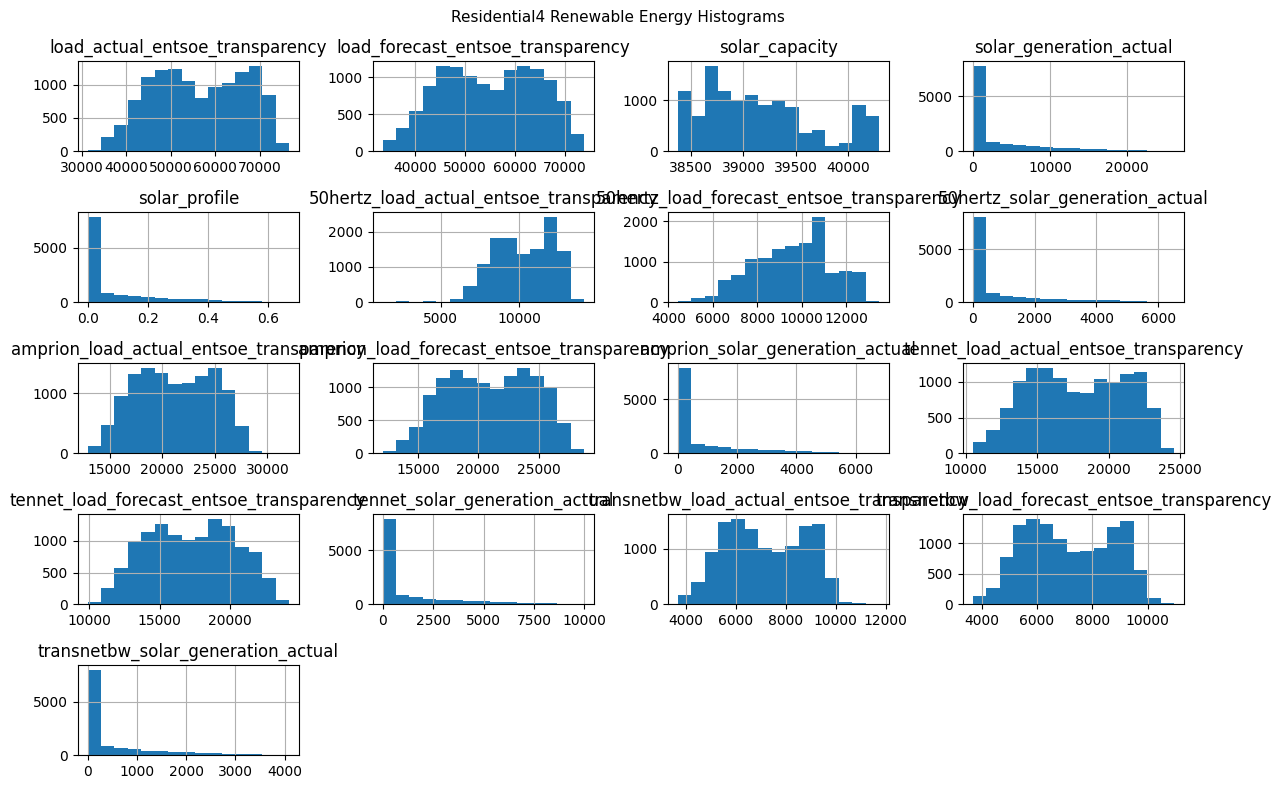

In [214]:
residential4_time.hist(bins=15, figsize=(12, 8))
plt.suptitle('Residential4 Renewable Energy Histograms', fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

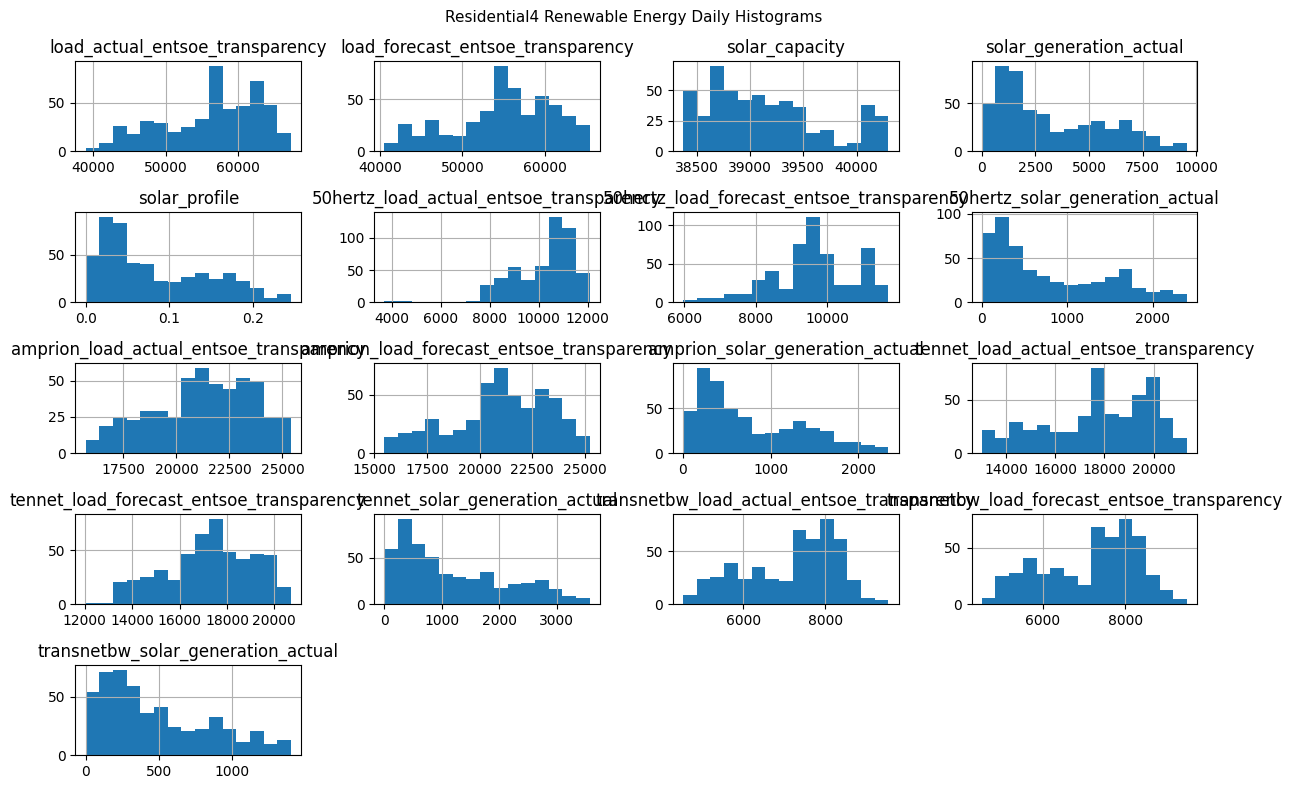

In [215]:
residential4_data_time_daily = residential4_time.resample('D').mean()
residential4_data_time_daily.hist(bins=15, figsize=(12, 8))
plt.suptitle('Residential4 Renewable Energy Daily Histograms', fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

Please take a look at this cols in order to determine which ones we can use as features for forecasting energy demand in residential4 data. [Link to README](https://data.open-power-system-data.org/time_series/2020-10-06/README.md).

Later, we can left join this with the residential4_data, since they share common indexes.

### Weather Dataset

In [216]:
residential4_weather = weather_data.loc[start_day:end_day]
residential4_weather = residential4_weather.filter(regex='^DE_')
residential4_weather.columns = residential4_weather.columns.str.replace('DE_', '', regex=False)
residential4_weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12239 entries, 2015-10-13 16:00:00+00:00 to 2017-03-06 14:00:00+00:00
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature                   12239 non-null  float64
 1   radiation_direct_horizontal   12239 non-null  float64
 2   radiation_diffuse_horizontal  12239 non-null  float64
dtypes: float64(3)
memory usage: 382.5 KB


#### Weather Data Variables

The dataset includes the following weather variables for Germany (DE):

* **temperature** - Temperature in degrees Celsius (°C)
* **radiation_direct_horizontal** - Direct solar radiation hitting a horizontal surface in watts per square meter (W/m²)
* **radiation_diffuse_horizontal** - Diffuse solar radiation hitting a horizontal surface in watts per square meter (W/m²)

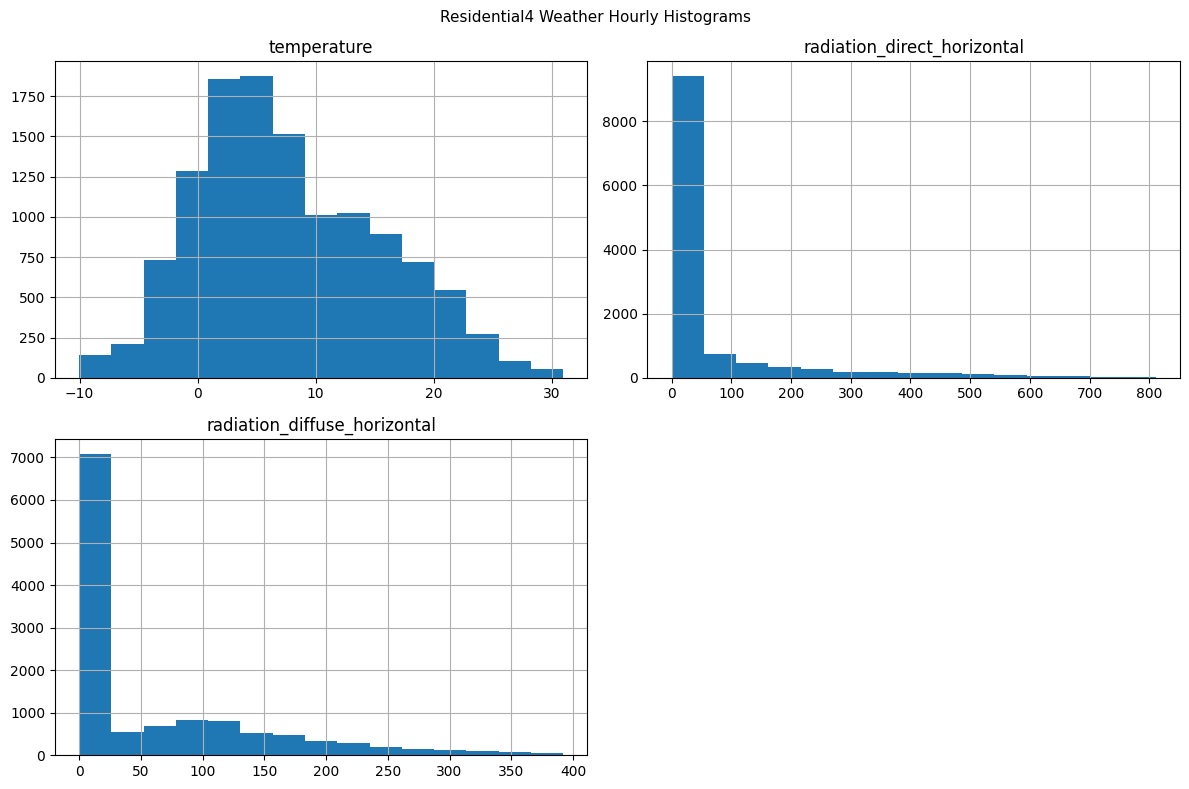

In [217]:
residential4_weather.hist(bins=15, figsize=(12, 8))
plt.suptitle('Residential4 Weather Hourly Histograms', fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show() 

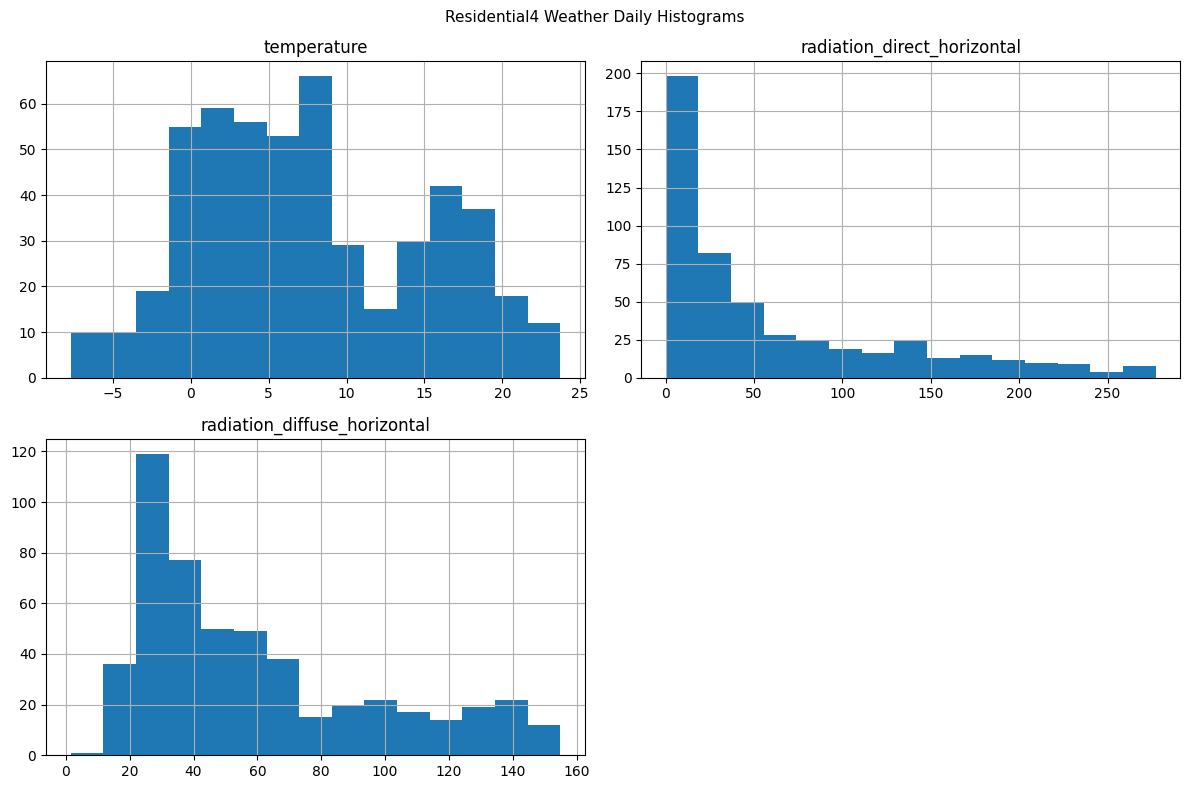

In [218]:
residential4_weather_daily = residential4_weather.resample('D').mean()
residential4_weather_daily.hist(bins=15, figsize=(12, 8))
plt.suptitle('Residential4 Weather Daily Histograms', fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

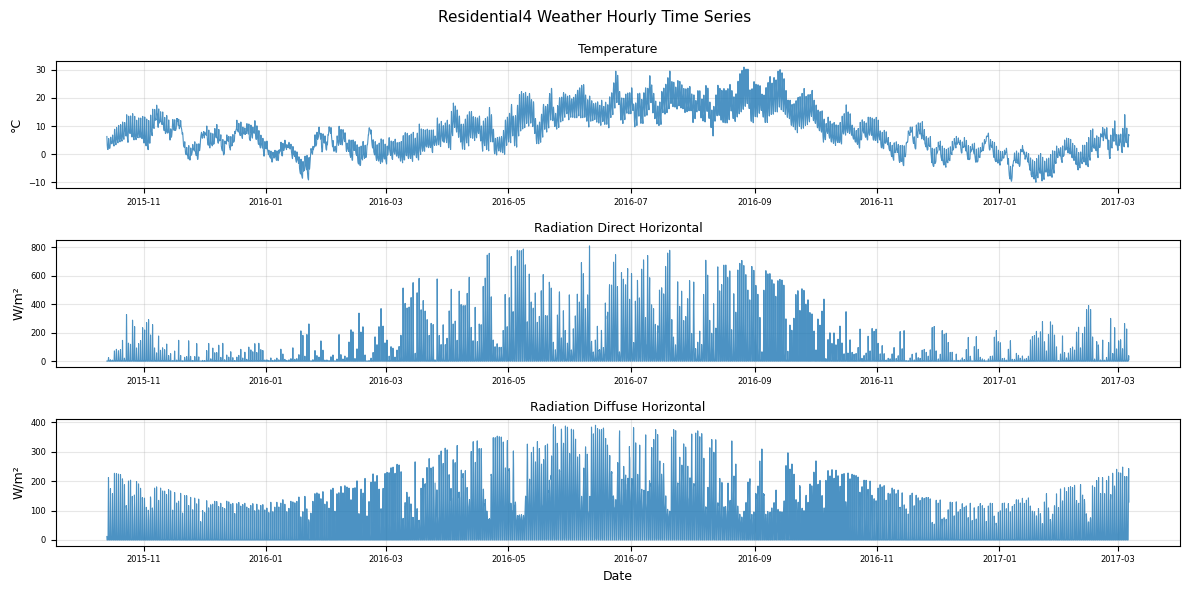

In [219]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
fig.suptitle('Residential4 Weather Hourly Time Series', fontsize=TITLE_FONTSIZE)
# Temperature
axes[0].plot(residential4_weather.index, residential4_weather['temperature'],
                linewidth=0.8, alpha=0.8)
axes[0].set_title('Temperature', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('°C', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[0].grid(True, alpha=0.3)

# Radiation direct horizontal
axes[1].plot(residential4_weather.index, residential4_weather['radiation_direct_horizontal'],
                linewidth=0.8, alpha=0.8)
axes[1].set_title('Radiation Direct Horizontal', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('W/m²', fontsize=LABEL_FONTSIZE)
axes[1].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[1].grid(True, alpha=0.3)

# WRadiation diffuse horizontal
axes[2].plot(residential4_weather.index, residential4_weather['radiation_diffuse_horizontal'],
                linewidth=0.8, alpha=0.8)
axes[2].set_title('Radiation Diffuse Horizontal', fontsize=LABEL_FONTSIZE)
axes[2].set_ylabel('W/m²', fontsize=LABEL_FONTSIZE)
axes[2].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
axes[2].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

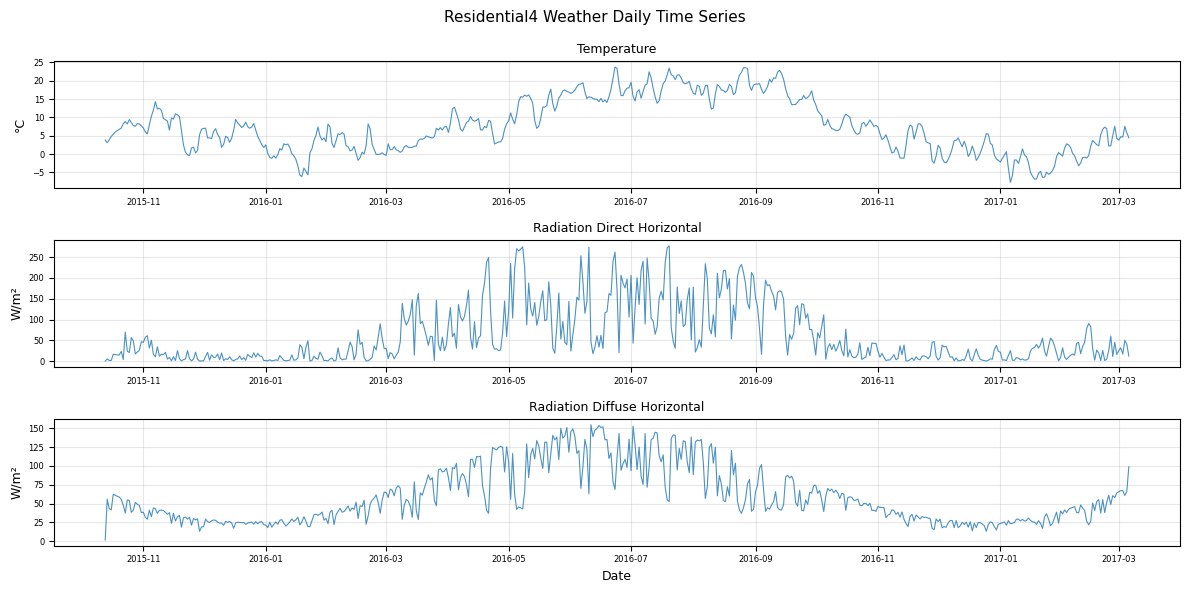

In [220]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
fig.suptitle('Residential4 Weather Daily Time Series', fontsize=TITLE_FONTSIZE)
# Temperature
axes[0].plot(residential4_weather_daily.index, residential4_weather_daily['temperature'],
                linewidth=0.8, alpha=0.8)
axes[0].set_title('Temperature', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('°C', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[0].grid(True, alpha=0.3)

# Radiation direct horizontal
axes[1].plot(residential4_weather_daily.index, residential4_weather_daily['radiation_direct_horizontal'],
                linewidth=0.8, alpha=0.8)
axes[1].set_title('Radiation Direct Horizontal', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('W/m²', fontsize=LABEL_FONTSIZE)
axes[1].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[1].grid(True, alpha=0.3)

# WRadiation diffuse horizontal
axes[2].plot(residential4_weather_daily.index, residential4_weather_daily['radiation_diffuse_horizontal'],
                linewidth=0.8, alpha=0.8)
axes[2].set_title('Radiation Diffuse Horizontal', fontsize=LABEL_FONTSIZE)
axes[2].set_ylabel('W/m²', fontsize=LABEL_FONTSIZE)
axes[2].set_xlabel('Date', fontsize=LABEL_FONTSIZE)
axes[2].tick_params(labelsize=TICK_LABEL_FONTSIZE)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [221]:
# Left join: residential4_data (left) with residential4_weather (right) on index (dates)
residential4_hourly_merged = residential4_data_hourly.join(residential4_weather, how='left')

residential4_hourly_merged.head()


,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
utc_timestamp,,,,,,,,,,,,
2015-10-13 17:00:00+00:00,0.002,0.57,0.018,0.0,1.248,0.470,0.0,NaN,0.002,5.224,0.0,0.0
2015-10-13 18:00:00+00:00,0.000,0.00,0.026,0.0,0.765,0.530,0.0,NaN,0.000,4.540,0.0,0.0
2015-10-13 19:00:00+00:00,0.000,0.00,0.020,0.0,0.701,0.430,0.0,NaN,0.000,3.843,0.0,0.0
2015-10-13 20:00:00+00:00,0.000,0.00,0.017,0.0,0.573,0.350,0.0,NaN,0.000,3.196,0.0,0.0
2015-10-13 21:00:00+00:00,0.000,0.00,0.029,0.0,0.662,0.436,0.0,NaN,0.000,2.757,0.0,0.0


In [222]:
residential4_hourly_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12238 entries, 2015-10-13 17:00:00+00:00 to 2017-03-06 14:00:00+00:00
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   dishwasher                    12238 non-null  float64
 1   ev                            12238 non-null  float64
 2   freezer                       12238 non-null  float64
 3   grid_export                   12238 non-null  float64
 4   grid_import                   12238 non-null  float64
 5   heat_pump                     12238 non-null  float64
 6   pv                            12238 non-null  float64
 7   refrigerator                  10763 non-null  float64
 8   washing_machine               12238 non-null  float64
 9   temperature                   12238 non-null  float64
 10  radiation_direct_horizontal   12238 non-null  float64
 11  radiation_diffuse_horizontal  12238 non-null  float64
dtypes: float64(12

In [223]:
residential4_daily_merged = residential4_data_daily.join(residential4_weather_daily, how='left')   
residential4_daily_merged.head()

,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
utc_timestamp,,,,,,,,,,,,
2015-10-14 00:00:00+00:00,0.009458,3.801208,0.344667,4.847500,8.733000,6.491625,9.906250,NaN,0.004542,3.088417,5.377025,55.964250
2015-10-15 00:00:00+00:00,0.473000,3.952000,0.509542,4.565792,8.840375,5.277917,10.963958,0.290500,0.006667,3.882417,1.886054,43.256808
2015-10-16 00:00:00+00:00,0.468375,2.327250,0.498083,2.365208,13.924917,10.344583,6.637250,0.348917,0.004750,4.813750,1.658937,41.459929
2015-10-17 00:00:00+00:00,0.009917,4.115250,0.495875,2.849958,16.025792,11.119208,7.825333,0.377000,0.004750,5.372500,16.392312,62.422004
2015-10-18 00:00:00+00:00,0.581167,5.184708,0.492042,1.611875,17.262167,10.978875,6.890042,0.375542,0.007833,5.974083,16.178633,60.851612


In [224]:
residential4_daily_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 510 entries, 2015-10-14 00:00:00+00:00 to 2017-03-06 00:00:00+00:00
Freq: D
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   dishwasher                    510 non-null    float64
 1   ev                            510 non-null    float64
 2   freezer                       510 non-null    float64
 3   grid_export                   510 non-null    float64
 4   grid_import                   510 non-null    float64
 5   heat_pump                     510 non-null    float64
 6   pv                            510 non-null    float64
 7   refrigerator                  448 non-null    float64
 8   washing_machine               510 non-null    float64
 9   temperature                   510 non-null    float64
 10  radiation_direct_horizontal   510 non-null    float64
 11  radiation_diffuse_horizontal  510 non-null    float64
dtypes: floa

#### Correlation with target variable

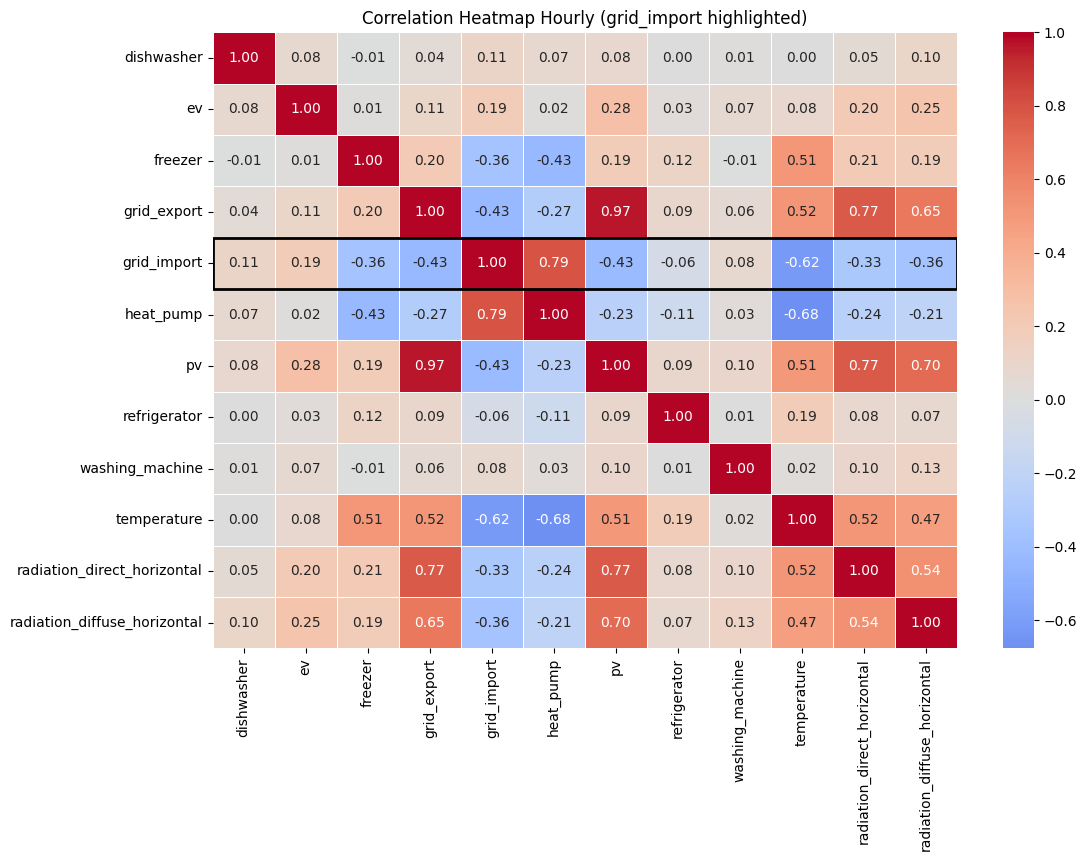

In [225]:
plt.figure(figsize=(12, 8))
corr = residential4_hourly_merged.corr()
target = list(corr.columns).index('grid_import')

ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, center=0)

ax.add_patch(plt.Rectangle((0, target), len(corr), 1, fill=False, edgecolor='black', lw=2))

plt.title("Correlation Heatmap Hourly (grid_import highlighted)")
plt.show()

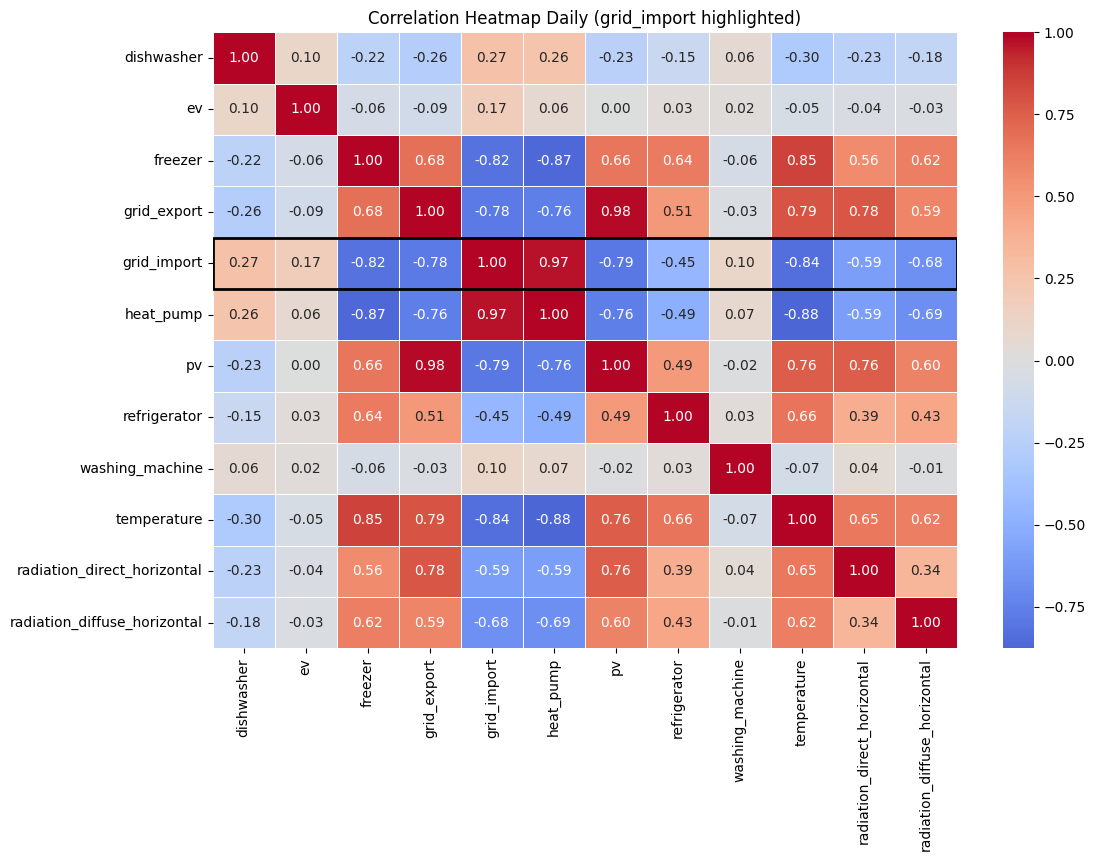

In [226]:
plt.figure(figsize=(12, 8))
corr = residential4_daily_merged.corr()
target = list(corr.columns).index('grid_import')

ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, center=0)

ax.add_patch(plt.Rectangle((0, target), len(corr), 1, fill=False, edgecolor='black', lw=2))

plt.title("Correlation Heatmap Daily (grid_import highlighted)")
plt.show()

Based on the correlation matrix for hourly data, the `refrigerator` variable shows a very weak relationship with the target variable. Compared to other variables such as heat_pump (0.79) or pv (-0.43), its contribution appears negligible.

Consequently, due to both low predictive relevance and significant missing data, the refrigerator variable is removed from the dataset.

In [227]:
residential4_hourly_merged = residential4_hourly_merged.drop(columns = ["refrigerator"])
residential4_daily_merged = residential4_daily_merged.drop(columns = ["refrigerator"])

In [228]:
merged_data_dir = os.path.join(parent_dir, 'data/raw')
processed_data_hourly_path = os.path.join(merged_data_dir, 'residential4_hourly_merged.csv')
residential4_hourly_merged.to_csv(processed_data_hourly_path)

processed_data_daily_path = os.path.join(merged_data_dir, 'residential4_daily_merged.csv')
residential4_daily_merged.to_csv(processed_data_daily_path)